# Embeddings con Skip-gram en PyTorch
Implementamos un modelo **Skip-gram** para aprender embeddings de palabras desde contexto.

## Skip-gram en una idea
- Entrada: palabra central.
- Objetivo: predecir palabras vecinas.
- Resultado: palabras con contextos similares quedan cerca en el espacio vectorial.

## Supervisado vs Skip-gram
- **Supervisado**: usa pares (entrada, etiqueta) anotados.
- **Skip-gram**: usa el propio texto para generar objetivos de contexto (auto-supervisado).

Ambos entrenan igual: prediccion -> perdida -> backprop -> actualizacion de pesos.

## Objetivos
- Construir pares (palabra central, contexto).
- Entrenar un modelo Skip-gram simple.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reproducibilidad
torch.manual_seed(42)

## 2) Corpus de ejemplo
Usamos un corpus pequeño para ilustrar la lógica de Skip-gram.

In [15]:
sentences = [
    "Representar el mundo con números está chido",
    "Palabras similares viven en la misma cuadra",
    "En Ciencias los embeddings son puro estilo",
    "El profesor Barrios domina el espacio vectorial",
    "Cercanía en el embedding es pura buena vibra",
    "La UNAM es donde el lenguaje se vuelve geometría",
    "Hay muchos alumnos que entienden los embeddings, pero los que lo hacen son genios",
    "Hay pocos alumnos que estudian matematicas aplicadas",

]
sentences

['Representar el mundo con números está chido',
 'Palabras similares viven en la misma cuadra',
 'En Ciencias los embeddings son puro estilo',
 'El profesor Barrios domina el espacio vectorial',
 'Cercanía en el embedding es pura buena vibra',
 'La UNAM es donde el lenguaje se vuelve geometría',
 'Hay muchos alumnos que entienden los embeddings, pero los que lo hacen son genios',
 'Hay pocos alumnos que estudian matematicas aplicadas']

## 3) Dataset Skip-gram
Generamos pares (palabra central, palabra de contexto) usando una ventana configurable.

In [16]:
class DatasetSkipGram(Dataset):
    def __init__(self, sentences, window=2):
        super().__init__()
        self.sentences = sentences
        self.window = window
        self.vocab = self.get_vocab(sentences)
        self.word_to_idx = {word: i for i, word in enumerate(self.vocab)}
        self.idx_to_word = {i: word for i, word in enumerate(self.vocab)}
        self.data = self.gen_dataset()

    def get_vocab(self, sentences):
        tokens = [token.lower() for sentence in sentences for token in sentence.split()]
        return sorted(set(tokens))

    def gen_dataset(self):
        data = []
        for sentence in self.sentences:
            tokens = sentence.lower().split()
            for center_idx, center_word in enumerate(tokens):
                for offset in range(-self.window, self.window + 1):
                    context_idx = center_idx + offset
                    if context_idx < 0 or context_idx >= len(tokens) or context_idx == center_idx:
                        continue
                    context_word = tokens[context_idx]
                    data.append((self.word_to_idx[center_word], self.word_to_idx[context_word]))
        return data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = DatasetSkipGram(sentences, window=2)
len(dataset), len(dataset.vocab)

(216, 51)

In [17]:
dataset.vocab

['alumnos',
 'aplicadas',
 'barrios',
 'buena',
 'cercanía',
 'chido',
 'ciencias',
 'con',
 'cuadra',
 'domina',
 'donde',
 'el',
 'embedding',
 'embeddings',
 'embeddings,',
 'en',
 'entienden',
 'es',
 'espacio',
 'estilo',
 'estudian',
 'está',
 'genios',
 'geometría',
 'hacen',
 'hay',
 'la',
 'lenguaje',
 'lo',
 'los',
 'matematicas',
 'misma',
 'muchos',
 'mundo',
 'números',
 'palabras',
 'pero',
 'pocos',
 'profesor',
 'pura',
 'puro',
 'que',
 'representar',
 'se',
 'similares',
 'son',
 'unam',
 'vectorial',
 'vibra',
 'viven',
 'vuelve']

In [19]:
for x, y in dataset:
    print(f"Center: {dataset.idx_to_word[x]}, Context: {dataset.idx_to_word[y]}")   

Center: representar, Context: el
Center: representar, Context: mundo
Center: el, Context: representar
Center: el, Context: mundo
Center: el, Context: con
Center: mundo, Context: representar
Center: mundo, Context: el
Center: mundo, Context: con
Center: mundo, Context: números
Center: con, Context: el
Center: con, Context: mundo
Center: con, Context: números
Center: con, Context: está
Center: números, Context: mundo
Center: números, Context: con
Center: números, Context: está
Center: números, Context: chido
Center: está, Context: con
Center: está, Context: números
Center: está, Context: chido
Center: chido, Context: números
Center: chido, Context: está
Center: palabras, Context: similares
Center: palabras, Context: viven
Center: similares, Context: palabras
Center: similares, Context: viven
Center: similares, Context: en
Center: viven, Context: palabras
Center: viven, Context: similares
Center: viven, Context: en
Center: viven, Context: la
Center: en, Context: similares
Center: en, Cont

In [20]:
len(dataset.vocab)

51

## 4) Modelo Skip-gram
Usamos dos capas lineales sin bias para mostrar la equivalencia didáctica con embeddings + proyección al vocabulario.

In [21]:
class SkipGram(nn.Module):
    def __init__(self, vocab_size, embedding_size):
        super().__init__()
        self.embed_layer = nn.Linear(vocab_size, embedding_size, bias=False)
        self.output_layer = nn.Linear(embedding_size, vocab_size, bias=False)

    def forward(self, x):
        x = self.embed_layer(x)
        x = self.output_layer(x)
        return x

## 5) Entrenamiento
Entrenamos con **CrossEntropyLoss** y optimizador **Adam**.

In [22]:
def train(model, loss_function, optimizer, dataloader, epochs=500):
    model.train()
    vocab_size = len(dataloader.dataset.vocab)

    for epoch in range(epochs):
        total_loss = 0.0
        for center_idx, context_idx in dataloader:
            center_idx = center_idx.item()
            context_idx = context_idx.long()

            center_vector = torch.zeros(1, vocab_size)
            center_vector[0, center_idx] = 1.0
            
            optimizer.zero_grad()
            output = model(center_vector)
            loss = loss_function(output, context_idx)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1}, Loss: {total_loss:.4f}")

## 6) Ejecucion y visualizacion de embeddings
Entrenamos, extraemos la matriz de embeddings y la proyectamos en 2D con t-SNE.

In [23]:
dataset = DatasetSkipGram(sentences, window=2)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

model = SkipGram(vocab_size=len(dataset.vocab), embedding_size=50)

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

train(model, loss_fn, optimizer, dataloader, epochs=400)


Epoch 100, Loss: 596.0490
Epoch 200, Loss: 403.7498
Epoch 300, Loss: 360.3442
Epoch 400, Loss: 347.7361


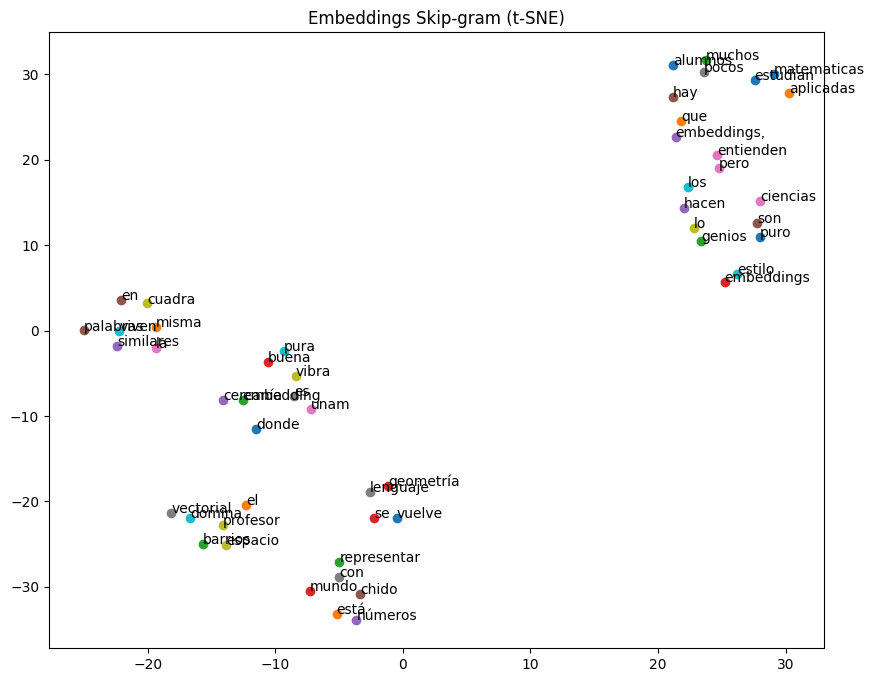

In [24]:
embeddings = model.embed_layer.weight.detach().t().numpy()

# t-SNE requiere al menos 2 y menos que n_samples dimensiones de perplexity
perplexity = min(5, len(dataset.vocab) - 1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
reduced_embeddings = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
for i, word in enumerate(dataset.vocab):
    plt.scatter(reduced_embeddings[i, 0], reduced_embeddings[i, 1])
    plt.annotate(word, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]))
plt.title("Embeddings Skip-gram (t-SNE)")
plt.show()

In [10]:
embeddings.shape, len(dataset.vocab)

((37, 200), 37)

In [25]:
len(embeddings[0]),embeddings[0]


(50,
 array([ 0.8463358 ,  0.2160255 ,  0.20359871, -0.14039281, -0.37140515,
        -0.9089585 , -0.45270944, -0.85455614,  0.283803  , -0.83822864,
        -0.61219174,  0.61835647,  0.04109904, -0.15493464,  0.8862876 ,
         0.28701723, -0.8082184 , -0.21082436,  0.25243047,  0.33069032,
        -0.93222654,  0.05031365, -0.943902  ,  0.19093646, -0.19064693,
         0.06047684,  0.7203409 , -0.10500369,  0.16100766,  0.36534297,
        -0.35939008,  0.07536396, -0.01154525, -0.5542286 ,  0.24355659,
         0.21059832, -0.65375483, -0.1508702 ,  0.37927976,  0.1575569 ,
         0.5069263 , -0.43586323, -0.02745609, -0.12157929,  0.09304376,
         0.21598941,  0.44313553, -0.05204838,  0.536823  ,  0.04392897],
       dtype=float32))

## Nota
En practica, para datos de mayor volumen se recomienda usar `nn.Embedding`.